**Importing the dependencies**

In [4]:
import pandas as pd                       # Pandas is used for working with tables (rows & columns) — like Excel
import seaborn as sns                     # Seaborn is a statistical data visualization library built on top of matplotlib
import matplotlib.pyplot as plt           # Matplotlib is the core plotting library in Python
import joblib                             # Joblib is used to save and load ML models
import numpy as np                        # NumPy is used for numerical computing
from sklearn.metrics import mean_squared_error, r2_score            # mean_squared_error used to evaluate regression models (Measures average squared error, Lower = better)
                                                                    # r2_score measures how well model explains variance (Closer to 1 = better)
from sklearn.preprocessing import StandardScaler                    # Used to scale features (mean = 0, std = 1), Improves model performance, Required for models like Linear Regression, SVM, KNN
from xgboost import XGBRegressor                                    # A powerful gradient boosting regression model, Handles non-linearity, Popular in competitions & industry
from sklearn.datasets import fetch_california_housing   # fetch_california_housing is used to load the built-in California Housing dataset from scikit-learn. It's commonly used for regression tasks such as predicting house prices
from sklearn.model_selection import train_test_split, GridSearchCV   # train_test_split (split data into training and testing sets), GridSearchCV (Finds best hyperparameters, & Uses cross-validation)
from sklearn.linear_model import LinearRegression                    # A basic regression model

**Data fetching and understanding**

In [5]:
# Load the dataset and return it directly as a DataFrame-friendly object, making it easier to work with.
california_housing = fetch_california_housing(as_frame=True)     # fetch_california_housing (used to load a real-world regression dataset), as_frame=True (Converts the data into pandas DataFrame & Series)

In [6]:
# We can also make the dataframe by defining it as df = california_housing.frame, df.head()
california_housing

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude 

In [7]:
df = california_housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
x = california_housing.data
y = california_housing.target

In [9]:
x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [10]:
#y is the target value
y

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [12]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [13]:
df.isnull().sum().sum()

np.int64(0)

In [15]:
df.duplicated().sum()

np.int64(0)

**Exploratory Data Analysis (EDA)**

In [14]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [16]:
df.shape

(20640, 9)

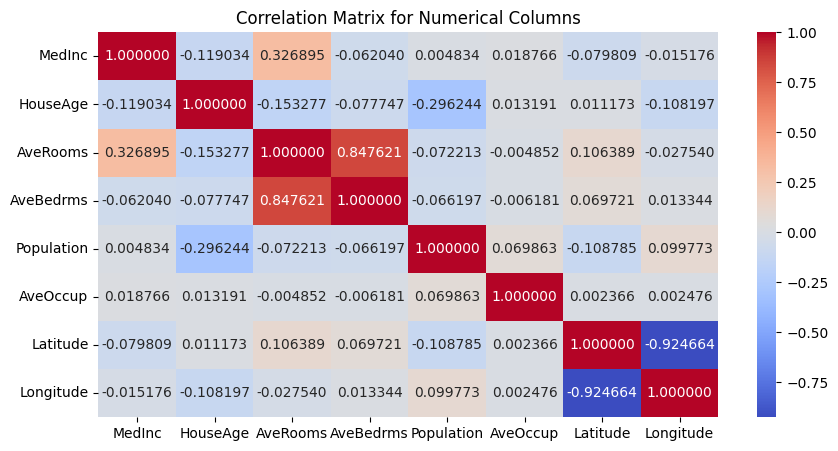

In [17]:
# Correlation between features themselves
# Detect multicollinearity
# Identify redundant features
# Prevent unstable linear models

plt.figure(figsize=(10,5))
sns.heatmap(df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup','Latitude', 'Longitude']].corr(), annot=True, cmap="coolwarm", fmt="2f")
plt.title("Correlation Matrix for Numerical Columns")
plt.show()

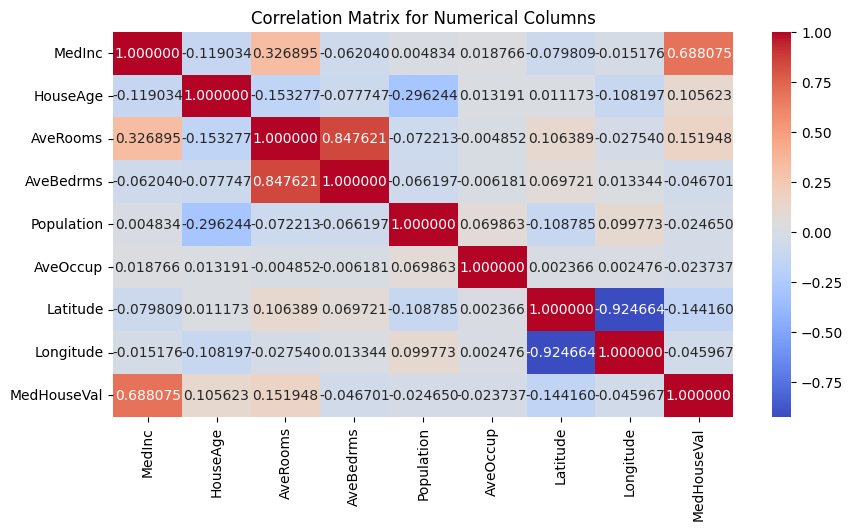

In [18]:
# Correlation Matrix - heatmap
# To see which features influence the target
# To understand predictive power
# To guide feature selection

plt.figure(figsize=(10,5))
sns.heatmap(df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup','Latitude', 'Longitude', 'MedHouseVal']].corr(), annot=True, cmap="coolwarm", fmt="2f")
plt.title("Correlation Matrix for Numerical Columns")
plt.show()

In [19]:
import math

def plot_histograms(df, columns, cols_per_row=3):
    n_cols = len(columns)
    n_rows = math.ceil(n_cols / cols_per_row)

    plt.figure(figsize=(cols_per_row * 5, n_rows * 3))

    for i, col in enumerate(columns, 1):
        plt.subplot(n_rows, cols_per_row, i)
        sns.histplot(df[col].dropna(), kde=True)

        # Mean & Median
        plt.axvline(df[col].mean(), color="red", linestyle="dashed", linewidth=1)
        plt.axvline(df[col].median(), color="green", linestyle="dashed", linewidth=1)

        plt.title(col)
        plt.tight_layout()

    plt.show()



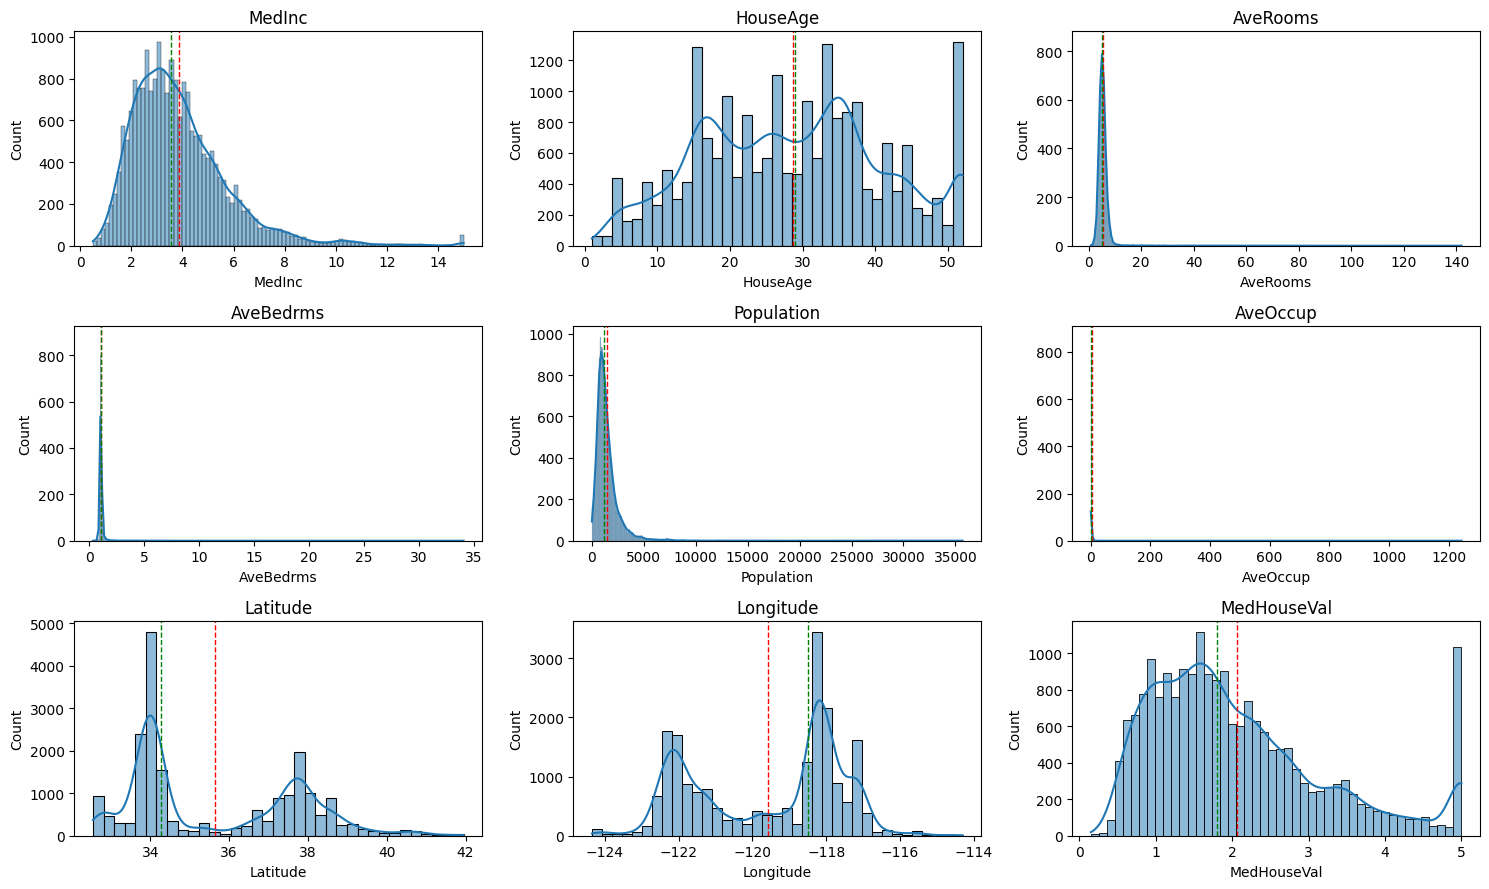

In [20]:
num_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
            'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
plot_histograms(df, num_cols)

**Training and Test Data**

In [26]:
# Now split the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [27]:
print("Training set:", x_train.shape, y_train.shape)
print("Testing set:", x_test.shape, y_test.shape)

Training set: (16512, 8) (16512,)
Testing set: (4128, 8) (4128,)


In [28]:
# Now scale our features We scale features so that no feature dominates others due to different magnitudes, improving accuracy, Model stability, and training speed.
# we would train x_train_scaled separately because we dont want data leakage
# Apply StandardScaler to bring all features to the same scale, so that models aren’t biased toward variables with larger ranges and
# convergence during training is faster and more stable
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)


In [32]:
# Because fit() learns statistics from the data, so in case of train we used but in case of test we dont do
x_test_scaled = scaler.transform(x_test)

In [31]:
#Train a baseline XG boost model
xgboost_baseline = XGBRegressor()
xgboost_baseline.fit(x_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [33]:
import warnings
warnings.filterwarnings('ignore')

In [34]:
# Now lets take predictions from our model
xgboost_baseline_y_pred = xgboost_baseline.predict(x_test_scaled)
xgboost_baseline_y_pred

array([0.5944522 , 0.7841187 , 5.1981163 , ..., 5.058281  , 0.76106036,
       1.8375903 ], dtype=float32)

In [35]:
# MSE measures the average squared difference between predicted values and actual values.
# If target variable (y) is normalized (for example, 0–1 range), then 0.22 is moderately small, meaning predictions are fairly close to actual values
# so less value is required to make model as better
mse = mean_squared_error(y_test, xgboost_baseline_y_pred)
mse

0.2225899267544737

In [36]:
# R² = 0.8301 → XGBoost model is performing well, explaining most of the variation in house prices.
# There is still some room for improvement, but overall the predictions are reliable.
# so higher value is required to make model as better

r2 = r2_score(y_test, xgboost_baseline_y_pred)
r2

0.8301370561019205

**Tune Parameters**

In [37]:
# Now Tune parameters
# Using GridSearchCV, it will train models for all possible combinations and pick the one with best performance (lowest error or highest R²/accuracy).
param_grid = {
    'n_estimators': [100, 200],             # n_estimators (number of trees)
    'learning_rate': [0.01, 0.1, 0.2],      # typical range 0.01 – 0.3
    'max_depth': [3, 5, 7],                 # max_depth (tree depth)Typical range: 3–10, often start small to prevent overfitting.
    'subsample': [0.8, 1.0],                # subsample (row sampling)  Typical range: 0.5 – 1.0
    'colsample_bytree': [0.8, 1.0]          # colsample_bytree (feature sampling)
}


In [38]:
grid_search = GridSearchCV(                       # GridSearchCV is used to find the best hyperparameters for a model by exhaustively searching over all combinations we provide in param_grid.
    estimator=XGBRegressor(),          # The base model we want to tune.
    param_grid=param_grid,             # This is the dictionary of hyperparameters defined earlier: GridSearchCV will try every possible combination of these values (2 × 3 × 3 × 2 × 2 = 72 combinations).
    scoring='r2',             # This tells GridSearchCV to evaluate each combination using the R² metric.  Higher R² → better fit.
    cv=5,                    #  5-fold cross-validation:  The training set is split into 5 parts. Each part is used once as a validation set while training on the other 4 parts. This gives a more robust evaluation of each hyperparameter combination.
    verbose=2,               # Prints detailed messages while the grid search runs.
    n_jobs=-1             # Speeds up training significantly, especially when there are many combinations.
)

In [39]:
grid_search.fit(x_train_scaled, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='r2', verbose=2)

In [40]:
grid_search.best_score_

np.float64(0.8443608340294138)

In [41]:
grid_search.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.1,
 'max_depth': 7,
 'n_estimators': 200,
 'subsample': 0.8}

In [43]:
# When we want to check the previous R square from the baseline model so clear the output of this
# above grid_search.fit(x_train_scaled, y_train) and as above r2 = 0.8301370561019205 and now
# we have grid_search.best_score_ as0.8443608340294138 as greater so it means we have improved
# our performance with hyperparamter tuning
# we can use this model like
grid_search.best_estimator_    # so now we dont need to train teh model we can directly use this

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [44]:
# now train model with best paramerters here we will pass the paramters into the xgboost regression for training a model just like a best estimater
best_params_ = grid_search.best_params_

In [45]:
# Now my model is ready like this
xgboost_final = XGBRegressor(**best_params_)
xgboost_final.fit(x_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [47]:
# Now visualize features in predicting prices
importances = xgboost_final.feature_importances_
importances

array([0.35319042, 0.05569689, 0.09466422, 0.02758164, 0.02544239,
       0.13182896, 0.1567948 , 0.15480055], dtype=float32)

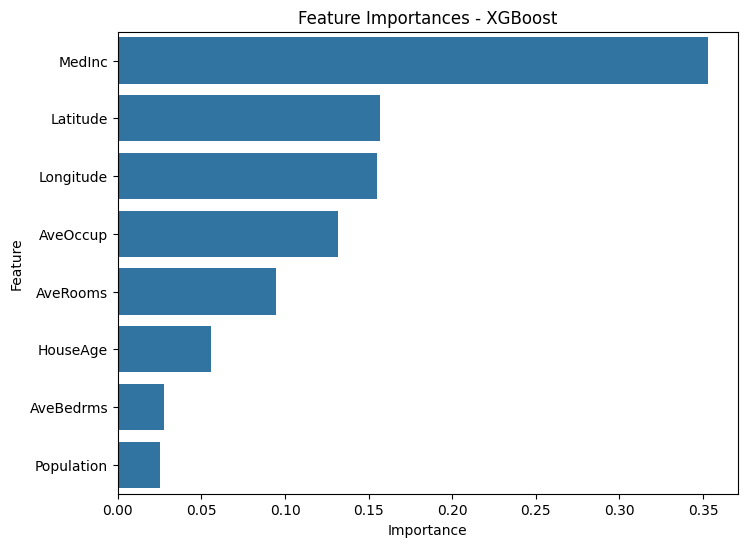

In [54]:
# So mst importance feature in predicting prices was Medinc Income and least importance was population
fi_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": loaded_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=fi_df,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importances - XGBoost")
plt.show()



In [55]:
# Now export model using joblib
joblib.dump(xgboost_final, 'xgboost_california_model.pkl')


['xgboost_california_model.pkl']

In [56]:
# Now to load the mdoel from the joblib
loaded_model = joblib.load('xgboost_california_model.pkl')

In [62]:
loaded_model.predict(x_test_scaled)

array([0.54652166, 0.9516871 , 5.258434  , ..., 4.7234416 , 0.6698863 ,
       1.7467821 ], dtype=float32)

In [60]:
# “For each house we input into the model, it predicts the expected price. The array you see is a list of these predicted prices.
# For instance, 0.5465 corresponds to $54,652, 5.2584 corresponds to $525,840, and so on. Overall, the model performs well — it explains 83% of the variation in housing prices
# and the average prediction error is relatively low.”